# Churn Prediction Model
Telecom customer churn dataset — predicting `Customer_Status = Churned` from account, service, and billing attributes.

This notebook builds on the EDA notebook (`churn_analysis_fixed.ipynb`) and reuses the same data-cleaning logic.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from xgboost import XGBClassifier

# Airtel theme colors, matching the Power BI dashboard
AIRTEL_RED = "#E40000"
AIRTEL_RED_DARK = "#8B0000"
AIRTEL_GREY = "#374150"
sns.set_style("whitegrid")


## 1. Load data

In [2]:
df = pd.read_csv("Customer_Data.csv")
print(df.shape)
df.head()


(6418, 32)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## 2. Data cleaning
Same fixes applied in the EDA notebook — the missing values here are structural (customer doesn't have that
service), not random, so we fill them with an explicit "No ..." category rather than the column mode.

In [3]:
service_cols = ['Internet_Type','Online_Security','Online_Backup','Device_Protection_Plan',
                'Premium_Support','Streaming_TV','Streaming_Movies','Streaming_Music','Unlimited_Data']
df[service_cols] = df[service_cols].fillna("No Internet Service")
df['Multiple_Lines'] = df['Multiple_Lines'].fillna("No Phone Service")
df['Value_Deal'] = df['Value_Deal'].fillna("No Deal")

# Monthly_Charge had a negative minimum in the EDA notebook - treat as bad data
df['Monthly_Charge'] = df['Monthly_Charge'].clip(lower=0)

df['Churn_Category'] = df['Churn_Category'].fillna("Not Churned")
df['Churn_Reason'] = df['Churn_Reason'].fillna("Not Churned")

print("Remaining nulls:", df.isnull().sum().sum())


Remaining nulls: 0


## 3. Handle the `Joined` segment separately
`Customer_Status` has three values: `Stayed`, `Churned`, `Joined`. `Joined` customers are brand-new — they
haven't been with the company long enough to churn or not, so including them in training would just add
label noise (this is a "censored" outcome, common in churn/survival problems).

**Approach:** train the model on `Stayed` vs `Churned` only. Afterwards, we'll run the trained model on the
`Joined` customers to flag which of these new customers already look at-risk — a genuinely useful output for
the business, not just a modeling footnote.

In [4]:
joined_df = df[df['Customer_Status'] == 'Joined'].copy()
model_df = df[df['Customer_Status'].isin(['Stayed', 'Churned'])].copy()

print("Training pool (Stayed/Churned):", model_df.shape)
print("Held-out Joined customers (scored later):", joined_df.shape)

model_df['Target'] = (model_df['Customer_Status'] == 'Churned').astype(int)
model_df['Target'].value_counts(normalize=True).rename('proportion')


Training pool (Stayed/Churned): (6007, 32)
Held-out Joined customers (scored later): (411, 32)


Target
0    0.71167
1    0.28833
Name: proportion, dtype: float64

## 4. Feature preparation
We drop:
- `Customer_ID` — identifier, not a feature
- `Customer_Status` — this is the label itself
- `Churn_Category`, `Churn_Reason` — these are only populated **after** a customer churns, so using them as
  predictors would be data leakage (the model would be cheating by seeing the outcome's own explanation).

In [5]:
drop_cols = ['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason']
X = model_df.drop(columns=drop_cols + ['Target'])
y = model_df['Target']

cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'string']).columns.tolist()
print(f"{len(cat_cols)} categorical columns, {len(num_cols)} numeric columns")

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Final feature matrix shape:", X_encoded.shape)


19 categorical columns, 9 numeric columns
Final feature matrix shape: (6007, 65)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Scale for Logistic Regression (tree models don't need this, but it doesn't hurt to keep one scaled copy)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: (4805, 65)  Test: (1202, 65)


## 5. Models
Three models, increasing in complexity: Logistic Regression (interpretable baseline), Random Forest, XGBoost.
`class_weight='balanced'` / `scale_pos_weight` account for the ~71/29 class split so the model doesn't just
learn to predict "Stayed" for everyone.

### 5a. Logistic Regression (baseline)

In [7]:
lr = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 4))


              precision    recall  f1-score   support

      Stayed       0.91      0.77      0.83       855
     Churned       0.59      0.81      0.68       347

    accuracy                           0.78      1202
   macro avg       0.75      0.79      0.76      1202
weighted avg       0.82      0.78      0.79      1202

ROC-AUC: 0.871


### 5b. Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))


              precision    recall  f1-score   support

      Stayed       0.89      0.87      0.88       855
     Churned       0.70      0.74      0.72       347

    accuracy                           0.83      1202
   macro avg       0.80      0.80      0.80      1202
weighted avg       0.84      0.83      0.83      1202

ROC-AUC: 0.8897


### 5c. XGBoost

In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                     scale_pos_weight=scale_pos_weight, random_state=42,
                     eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred, target_names=['Stayed', 'Churned']))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))


              precision    recall  f1-score   support

      Stayed       0.90      0.84      0.87       855
     Churned       0.66      0.77      0.71       347

    accuracy                           0.82      1202
   macro avg       0.78      0.81      0.79      1202
weighted avg       0.83      0.82      0.82      1202

ROC-AUC: 0.8919


## 6. Model comparison
Accuracy alone is misleading on imbalanced classes (a model predicting "Stayed" every time would still score
~71%). Compare precision/recall/F1 on the **Churned** class specifically, plus ROC-AUC.

In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)],
    'Precision (Churned)': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall (Churned)': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred), recall_score(y_test, xgb_pred)],
    'F1 (Churned)': [f1_score(y_test, lr_pred), f1_score(y_test, rf_pred), f1_score(y_test, xgb_pred)],
    'ROC-AUC': [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, xgb_proba)],
}).set_index('Model').round(3)

results


,Accuracy,Precision (Churned),Recall (Churned),F1 (Churned),ROC-AUC
Model,,,,,
Logistic Regression,0.781,0.588,0.810,0.681,0.871
Random Forest,0.833,0.699,0.738,0.718,0.890
XGBoost,0.820,0.663,0.769,0.712,0.892


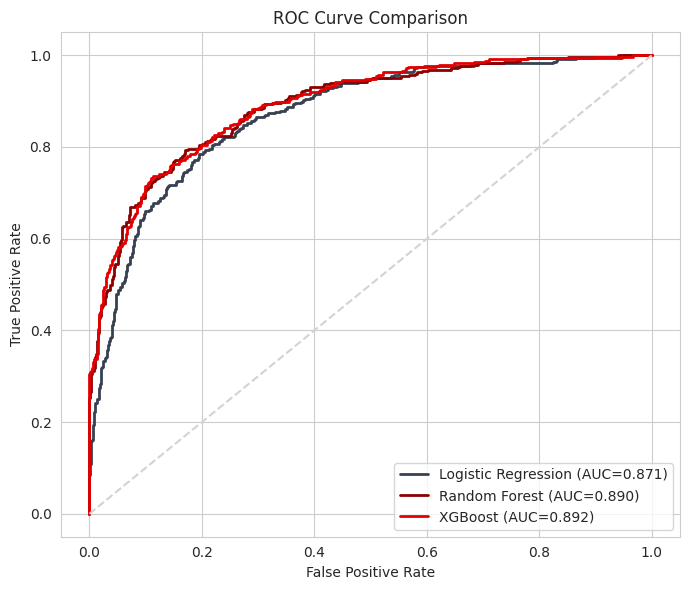

In [11]:
# ROC curves - all three models
plt.figure(figsize=(7, 6))
for name, proba, color in [('Logistic Regression', lr_proba, AIRTEL_GREY),
                            ('Random Forest', rf_proba, AIRTEL_RED_DARK),
                            ('XGBoost', xgb_proba, AIRTEL_RED)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='lightgrey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Confusion matrix — best model
Based on ROC-AUC and recall on the Churned class (the class we actually care about catching), pick the
strongest model going forward. Adjust `best_pred`/`best_name` below if a different model wins on your run.

Best model by ROC-AUC: XGBoost


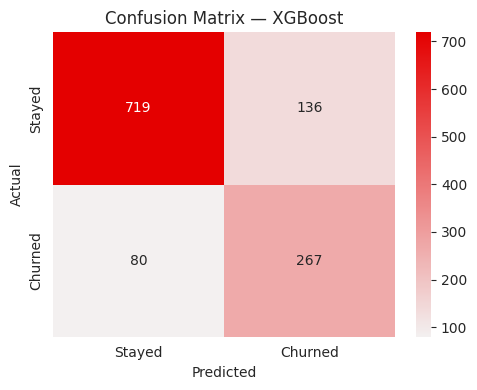

In [12]:
best_name = results['ROC-AUC'].idxmax()
best_pred = {'Logistic Regression': lr_pred, 'Random Forest': rf_pred, 'XGBoost': xgb_pred}[best_name]
best_proba = {'Logistic Regression': lr_proba, 'Random Forest': rf_proba, 'XGBoost': xgb_proba}[best_name]
print("Best model by ROC-AUC:", best_name)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(AIRTEL_RED, as_cmap=True),
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()


## 8. Feature importance
Which factors actually drive the model's churn predictions — this should line up with (and sharpen) the EDA insights from the first notebook.

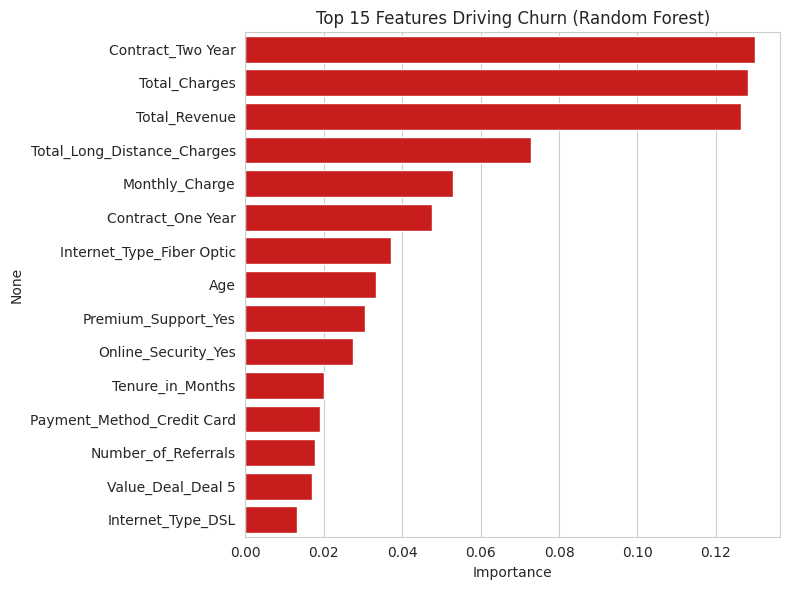

In [13]:
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color=AIRTEL_RED)
plt.title('Top 15 Features Driving Churn (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 9. Score the `Joined` customers
These are new customers with no churn outcome yet. Run the trained model on them to flag who already looks
at-risk based on the plan/services they signed up with — useful for early intervention.

In [14]:
X_joined = joined_df.drop(columns=['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'])
X_joined_encoded = pd.get_dummies(X_joined, columns=cat_cols, drop_first=True)

# align columns with training set (some categories may not appear in this small subset)
X_joined_encoded = X_joined_encoded.reindex(columns=X_encoded.columns, fill_value=0)

joined_df['Churn_Risk_Score'] = rf.predict_proba(X_joined_encoded)[:, 1]

at_risk = joined_df[['Customer_ID', 'Contract', 'Tenure_in_Months', 'Monthly_Charge', 'Churn_Risk_Score']] \
    .sort_values('Churn_Risk_Score', ascending=False)

at_risk.head(15)


,Customer_ID,Contract,Tenure_in_Months,Monthly_Charge,Churn_Risk_Score
5267,37131-MAH,Month-to-Month,2,89.25,0.981209
1097,66868-HAR,Month-to-Month,10,70.25,0.981095
5187,31129-AND,Month-to-Month,15,70.35,0.981014
3862,55043-UTT,Month-to-Month,17,69.90,0.980794
5596,52641-JHA,Month-to-Month,29,71.10,0.979982
1280,94070-JAM,Month-to-Month,3,90.10,0.976493
5174,39332-TEL,Month-to-Month,8,80.55,0.975597
3064,99855-MAH,Month-to-Month,29,69.70,0.974797
2392,73547-KAR,Month-to-Month,16,84.05,0.973399
982,84843-MAD,Month-to-Month,8,75.10,0.972229


In [15]:
at_risk.to_csv("joined_customers_churn_risk.csv", index=False)
print("Saved: joined_customers_churn_risk.csv —", at_risk.shape[0], "customers scored")


Saved: joined_customers_churn_risk.csv — 411 customers scored


## 10. Also score the full customer base (optional — for Power BI)
A "who's at risk right now" table across *all* current (`Stayed`) customers, ranked by predicted churn
probability. Bring this into Power BI alongside the dashboard to power a "customers to prioritize" view.

In [16]:
current_df = df[df['Customer_Status'] == 'Stayed'].copy()
X_current = current_df.drop(columns=['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'])
X_current_encoded = pd.get_dummies(X_current, columns=cat_cols, drop_first=True)
X_current_encoded = X_current_encoded.reindex(columns=X_encoded.columns, fill_value=0)

current_df['Churn_Risk_Score'] = rf.predict_proba(X_current_encoded)[:, 1]

risk_table = current_df[['Customer_ID', 'Contract', 'Tenure_in_Months', 'Monthly_Charge',
                          'Total_Revenue', 'Churn_Risk_Score']].sort_values('Churn_Risk_Score', ascending=False)

risk_table.to_csv("current_customers_churn_risk.csv", index=False)
print("Saved: current_customers_churn_risk.csv —", risk_table.shape[0], "customers scored")
risk_table.head(15)


Saved: current_customers_churn_risk.csv — 4275 customers scored


,Customer_ID,Contract,Tenure_in_Months,Monthly_Charge,Total_Revenue,Churn_Risk_Score
3272,17488-PUN,Month-to-Month,5,75.65,396.35,0.871677
2395,83187-UTT,Month-to-Month,7,70.50,418.08,0.864759
5685,22792-AND,Month-to-Month,34,94.10,752.89,0.847390
5221,45324-TAM,Month-to-Month,14,84.60,1048.19,0.830473
4994,64905-UTT,Month-to-Month,27,105.30,1479.17,0.827286
4732,28574-UTT,Month-to-Month,7,80.85,595.65,0.823820
3587,15154-MAD,Month-to-Month,11,94.75,936.67,0.819615
5127,36369-MAH,Month-to-Month,13,75.85,790.53,0.818224
6101,28033-ASS,Month-to-Month,20,84.05,1180.75,0.813010
2274,99306-MAH,Month-to-Month,10,78.10,1184.70,0.807991


## Summary

- Trained on `Stayed` vs `Churned` only; `Joined` customers were excluded from training (no churn outcome yet)
  and instead scored separately as an early-warning list.
- `Churn_Category` / `Churn_Reason` were excluded as features — they're only known *after* churn happens, so
  using them would leak the answer into the model.
- Compare the three models in the table in section 6 — pick the one with the best recall on the Churned class
  if the business priority is "catch as many at-risk customers as possible," or best precision if the priority
  is "don't waste retention offers on customers who wouldn't have churned anyway."
- `Contract` type, `Total_Charges`/`Total_Revenue`, and `Monthly_Charge` came out as leading predictors —
  consistent with the EDA findings in the first notebook.
- Two CSVs are exported for use in Power BI: risk scores for new (`Joined`) customers and for the full active
  (`Stayed`) base, so you can build a "customers to prioritize for retention" view alongside the churn
  dashboard.